Apple Inc. (AAPL) Historical Stock Market Analysis

Advanced Python for Data Analysis

Week 6 Internship Task

Prepared by:
Olufunmilola Ogunmefun 

AnalystLab Africa Internship

# Apple Inc. (AAPL) Historical Stock Analysis

## Table of Contents

1. Introduction
2. Import Libraries
3. Load Dataset
4. Data Exploration
5. Data Cleaning
6. Data Transformation
7. Exploratory Data Analysis
8. Time Series Analysis
9. Feature Engineering
10. Data Visualization
11. Key Insights
12. Conclusion
13. Recommendations

# 1. Introduction

This project analyzes Apple's historical stock market performance using Python and Pandas.

The objective is to perform advanced data transformation, time-series analysis, feature engineering, and visualization to identify market trends and generate meaningful insights.

Dataset Source:
Yahoo Finance

Programming Language:
Python

Libraries Used

- Pandas
- NumPy
- Matplotlib
- Seaborn

# 2. Import Required Libraries

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

# 3. Load Dataset

In [55]:
df = pd.read_csv(r"E:\aapl\AAPL_5Y_historical.csv", header=[0,1])

In [56]:
df.columns=['Date','Close','High','Low','Open','Volume']

df.head()

,Date,Close,High,Low,Open,Volume
0,Date,NaN,NaN,NaN,NaN,NaN
1,2021-07-08,139.623505,140.422794,137.118384,138.005412,105575500.0
2,2021-07-09,141.446274,141.972633,139.048377,139.145858,99890800.0
3,2021-07-12,140.851624,142.625679,140.364248,142.518456,76299700.0
4,2021-07-13,141.962875,143.736931,140.003629,140.393524,100827100.0


In [57]:
df = df[df["Date"] != "Date"].copy()

In [58]:
df.reset_index(drop=True, inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# 4. Data Exploration

In [59]:
df.head()

df.info()

df.describe()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1254 non-null   datetime64[ns]
 1   Close   1254 non-null   float64       
 2   High    1254 non-null   float64       
 3   Low     1254 non-null   float64       
 4   Open    1254 non-null   float64       
 5   Volume  1254 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 58.9 KB


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [60]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains historical daily stock prices of Apple Inc.

The dataset was inspected for:

- Missing values
- Duplicate records
- Data types
- Dataset dimensions

# 5. Data Cleaning

In [62]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [63]:
df.drop_duplicates(inplace=True)

In [64]:
df=df.sort_values("Date")

In [65]:
df.reset_index(drop=True,inplace=True)

### Data Cleaning Summary

The following preprocessing steps were performed:

- Removed unnecessary header row
- Converted Date column to datetime
- Converted numerical columns to appropriate data types
- Removed duplicate observations
- Sorted dataset chronologically

# 6. Data Transformation Using Pandas

In [66]:
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

In [67]:
df['Price_Range'] = df['High'] - df['Low']

Additional transformation steps included reordering columns for clarity and creating a Price Range feature (High minus Low) to capture daily trading range.


# 7. Time-Series Analysis

Time-series analysis examines how Apple's stock prices changed over time using the Date column. This analysis helps identify long-term trends, short-term fluctuations, seasonal patterns, and market volatility.

The following techniques were applied:

- Date and time manipulation
- Trend analysis
- Monthly performance analysis
- Rolling averages (7-day and 30-day)
- Daily return analysis
- Rolling volatility analysis

These analyses provide insights into the historical behavior of Apple's stock and support better understanding of market movements.

In [68]:
df["Year"]=df["Date"].dt.year


In [69]:
df["Month"]=df["Date"].dt.month_name()


In [70]:
df["Quarter"]=df["Date"].dt.quarter


In [71]:
df["Day"]=df["Date"].dt.day_name()


In [72]:
monthly_close=df.groupby("Month")["Close"].mean()


In [73]:
yearly_close=df.groupby("Year")["Close"].mean()


In [74]:
df["Daily Return"]=df["Close"].pct_change()*100


In [75]:
df["MA7"]=df["Close"].rolling(7).mean()


In [76]:
df["MA30"]=df["Close"].rolling(30).mean()


In [77]:
df["Volatility"]=df["Daily Return"].rolling(30).std()


In [78]:
monthly_return = df.resample("ME", on="Date")["Close"].last().pct_change() * 100


# 8. Feature Engineering

In [79]:
df["Daily Price Change"]=df["Close"]-df["Open"]

In [80]:
df["Percentage Change"]=((df["Close"]-df["Open"])/df["Open"])*100

# 9. Data Visualization

## Visualization 1: Apple Closing Price Trend



This line chart illustrates the movement of Apple's daily closing stock price throughout the analysis period. It helps identify overall trends, periods of growth, and temporary market declines.

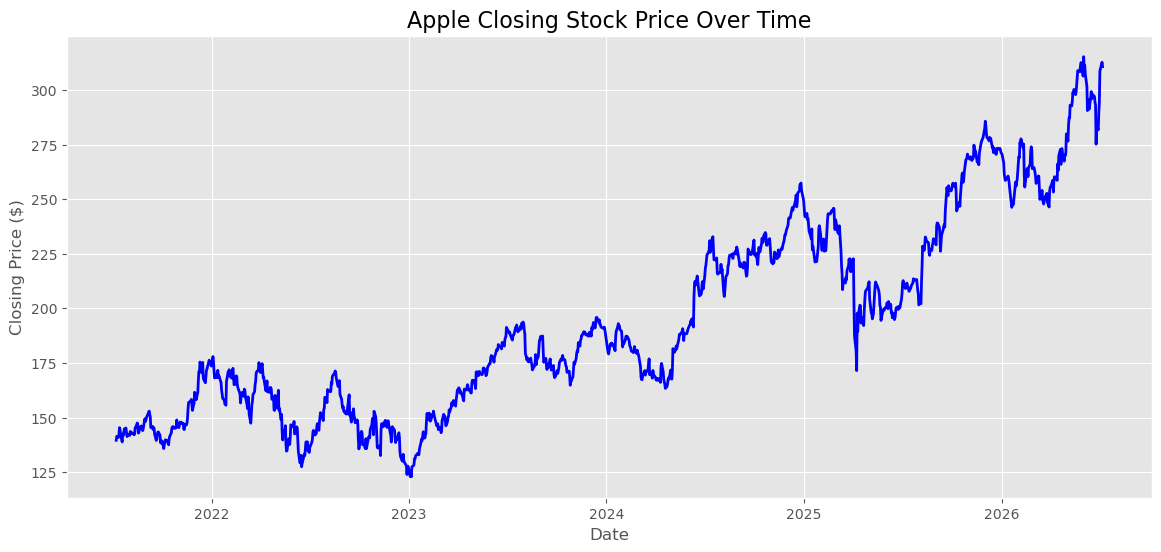

In [81]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], color='blue', linewidth=2)

plt.title('Apple Closing Stock Price Over Time', fontsize=16)

plt.xlabel('Date')

plt.ylabel('Closing Price ($)')

plt.grid(True)

plt.show()

## Visualization 2: Daily Trading Volume

This bar chart displays the daily trading volume of Apple shares. Higher trading volumes may indicate increased investor activity or important market events.

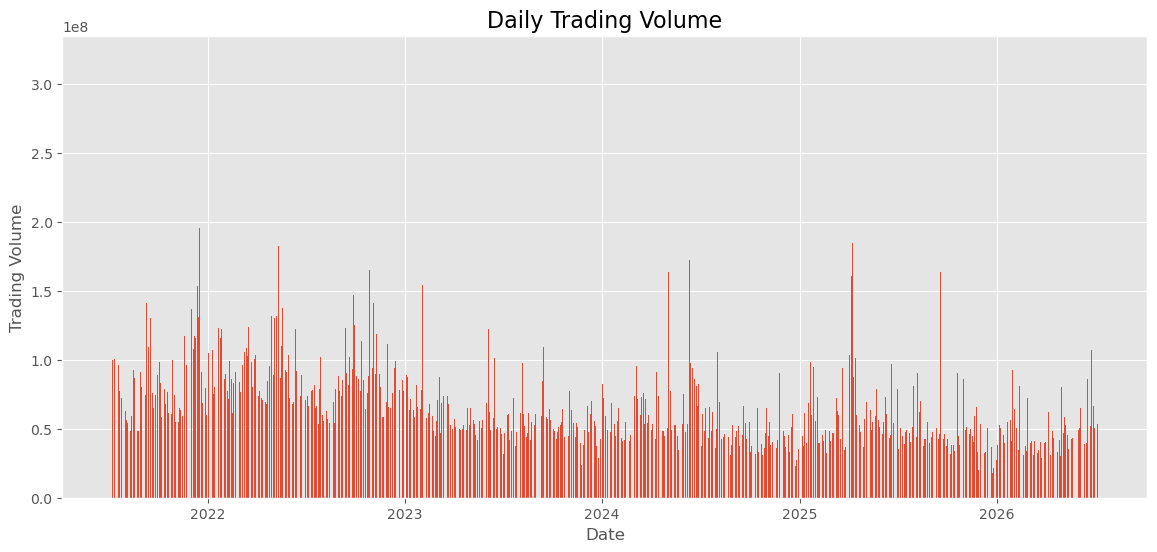

In [82]:
plt.figure(figsize=(14,6))

plt.bar(df['Date'], df['Volume'])

plt.title('Daily Trading Volume', fontsize=16)

plt.xlabel('Date')

plt.ylabel('Trading Volume')

plt.show()

## Visualization 3: Closing Price with 7-Day and 30-Day Moving Averages

This visualization compares the daily closing price with the 7-day and 30-day moving averages. Moving averages smooth short-term price fluctuations and make long-term trends easier to observe.s.

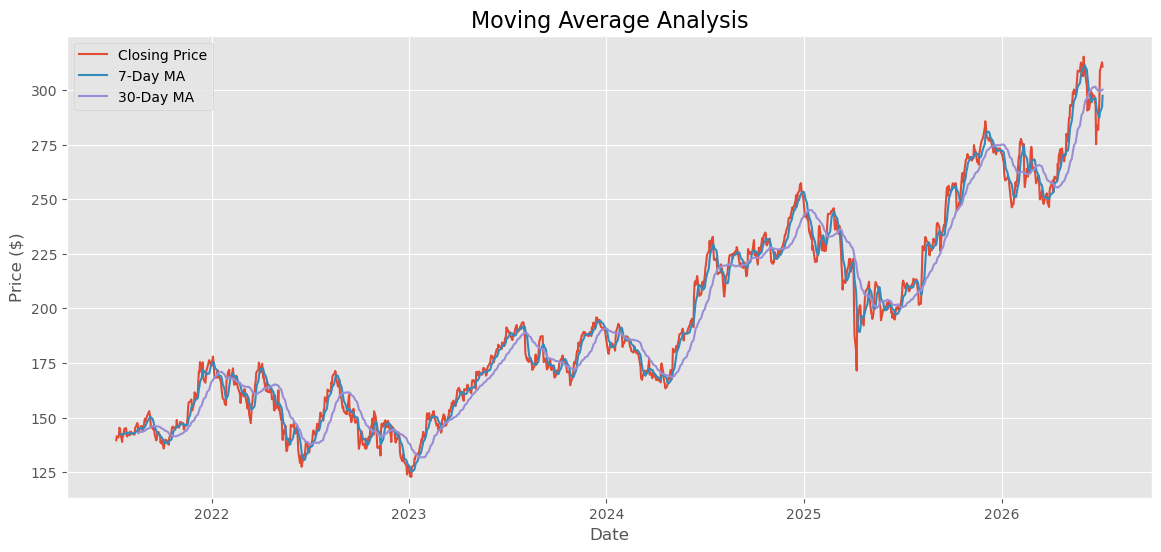

In [83]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Closing Price')

plt.plot(df['Date'], df['MA7'], label='7-Day MA')

plt.plot(df['Date'], df['MA30'], label='30-Day MA')

plt.title('Moving Average Analysis', fontsize=16)

plt.xlabel('Date')

plt.ylabel('Price ($)')

plt.legend()

plt.grid(True)

plt.show()

In [84]:
monthly_avg = df.resample('ME', on='Date')['Close'].mean()

## Visualization 4: Monthly Average Closing Price


This chart presents the average closing price for each month, allowing comparison of stock performance across different months and highlighting long-term market behavior.

In [85]:
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

monthly_avg = df.groupby('YearMonth')['Close'].mean()

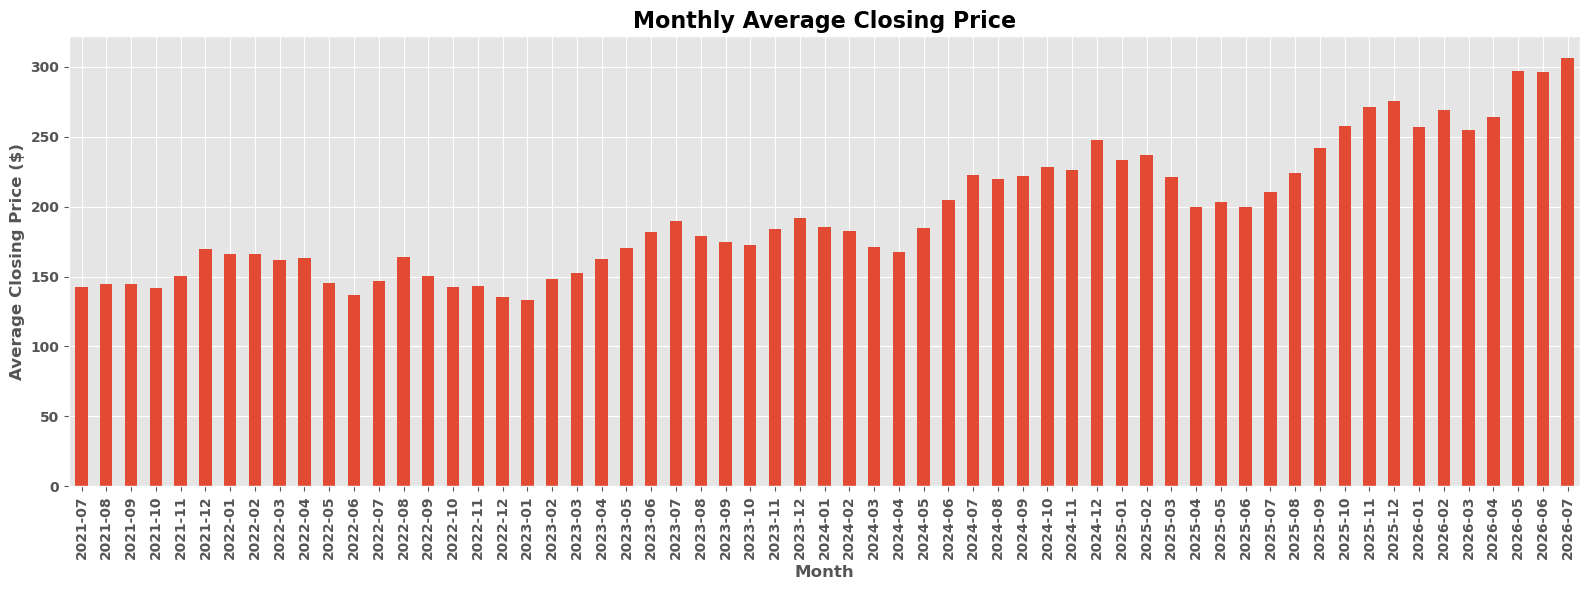

In [86]:
ax = monthly_avg.plot(kind='bar', figsize=(16,6))

plt.title('Monthly Average Closing Price', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Average Closing Price ($)', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, fontweight='bold')
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization 5: Distribution of Daily Returns

This histogram shows how Apple's daily returns are distributed. It helps determine whether daily price changes are generally small or if large gains and losses occur frequently.

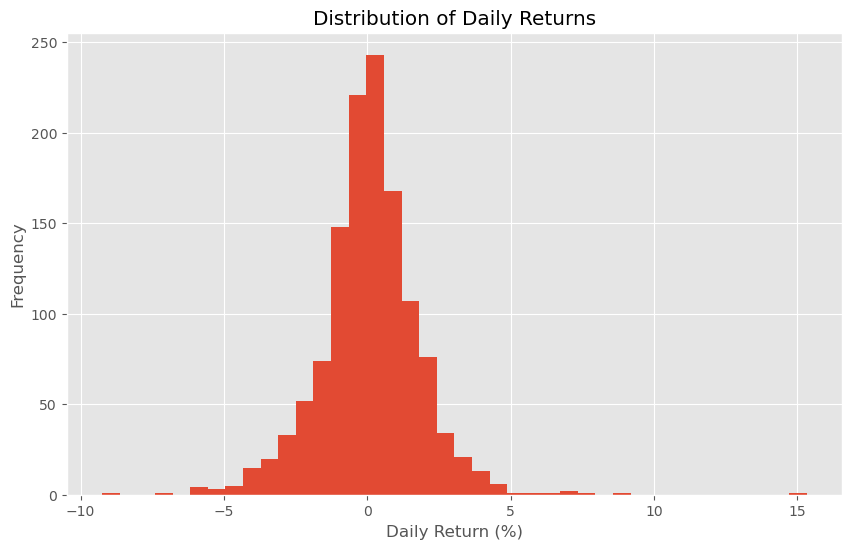

In [87]:
plt.figure(figsize=(10,6))

plt.hist(df['Daily Return'].dropna(), bins=40)

plt.title('Distribution of Daily Returns')

plt.xlabel('Daily Return (%)')

plt.ylabel('Frequency')

plt.show()

## Visualization 6: 30-Day Rolling Volatility

This line chart illustrates changes in the stock's rolling volatility over time. Higher volatility indicates greater price fluctuations and increased market uncertainty.

In [88]:
# Calculate Daily Return
df['Daily Return'] = df['Close'].pct_change() * 100

# Calculate 30-Day Rolling Volatility
df['Volatility'] = df['Daily Return'].rolling(window=30).std()

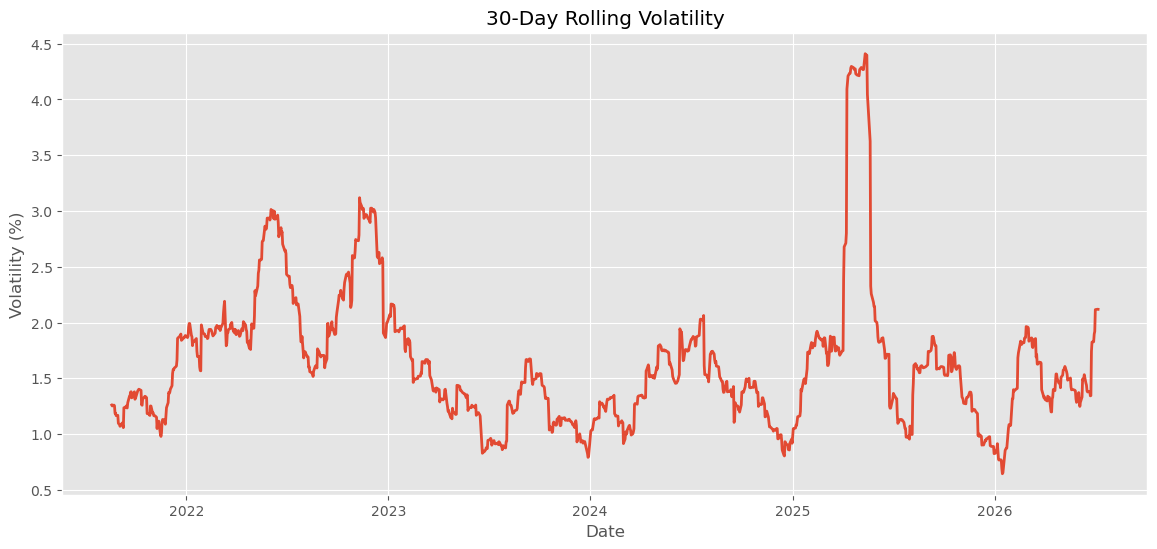

In [89]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Volatility'], linewidth=2)

plt.title('30-Day Rolling Volatility')

plt.xlabel('Date')

plt.ylabel('Volatility (%)')

plt.grid(True)

plt.show()

## Visualization 7: Correlation Heatmap

The correlation heatmap displays the relationships between numerical variables in the dataset. Strong positive correlations indicate variables that tend to move together, while weaker correlations suggest less direct relationships.

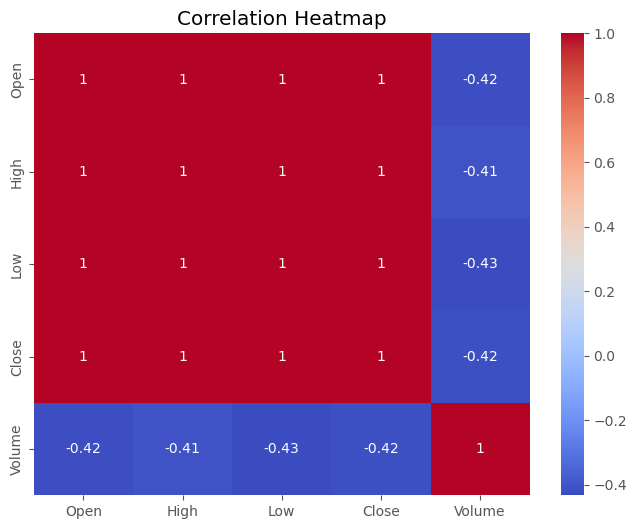

In [90]:
plt.figure(figsize=(8,6))

numeric = df[['Open','High','Low','Close','Volume']]

sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# 10. Key Findings


- Apple's closing stock price showed an overall upward trend during the period analyzed, although short-term price fluctuations occurred due to normal market movements.

- Trading volume varied throughout the dataset, with noticeable spikes on certain trading days, indicating periods of increased investor activity.

- The 7-day moving average responded quickly to recent price changes, while the 30-day moving average provided a smoother view of the long-term market trend.

- Monthly average closing prices showed that Apple's stock generally maintained positive performance over time despite temporary declines in some months.

- The distribution of daily returns revealed that most daily price changes were relatively small, while large gains and losses occurred less frequently.

- Rolling volatility changed over time, showing periods of higher market uncertainty followed by more stable trading conditions.

- The correlation analysis revealed strong positive relationships among the Open, High, Low, and Close prices, while Trading Volume showed a comparatively weaker relationship with stock prices.

# 11. Conclusion


This project demonstrated how Python and Pandas can be used to analyze historical stock market data effectively. Data cleaning, transformation, time-series analysis, and feature engineering made it possible to identify important trends and understand Apple's stock performance over time.

The visualizations highlighted changes in stock prices, trading activity, moving averages, daily returns, and market volatility, providing a comprehensive view of the company's historical market behavior. Overall, the analysis shows that combining data preparation with time-series techniques produces valuable insights that can support financial analysis and investment decision-making.

# 12. Recommendations


- Investors should monitor both short-term and long-term moving averages to better understand market trends before making investment decisions.

- Trading volume should be analyzed alongside price movements, as periods of unusually high volume may indicate significant market events or changes in investor sentiment.

- Volatility should be monitored regularly since increased volatility often reflects higher market risk and uncertainty.

- Future analyses can be enhanced by including additional technical indicators such as the Relative Strength Index (RSI), Moving Average Convergence Divergence (MACD), and Bollinger Bands.

- Incorporating external factors such as company earnings reports, interest rates, and economic news could provide a deeper understanding of stock price movements.

- Machine learning models can also be developed using the engineered features to forecast future stock prices and support predictive analysis.

# Skills Demonstrated

Throughout this project, the following skills were applied:

- Python Programming
- Pandas Data Manipulation
- NumPy
- Data Cleaning and Preprocessing
- Feature Engineering
- Time-Series Analysis
- Data Visualization
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Financial Data Analysis